# Etape 1: CLV historique et création de la target

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
import pandas as pd

transactions = pd.read_csv(r"C:\Users\reube\Data_marketing\transactions.csv")
transactions["invoice_date"] = pd.to_datetime(transactions["invoice_date"])
print(transactions["invoice_date"].dtype)

datetime64[us]


In [10]:
df_clean = transactions.copy()

# 1) Retirer les lignes sans client (indispensable TP2)
df_clean = df_clean.dropna(subset=["customer_id"])

# 2) Retirer prix négatifs / nuls
df_clean = df_clean[df_clean["unit_price"] > 0]

# 3) Retirer quantités négatives / nulles (retours, annulations)
df_clean = df_clean[df_clean["quantity"] > 0]

# 4) Retirer dates invalides
df_clean = df_clean.dropna(subset=["invoice_date"])

# 5) Retirer doublons exacts
df_clean = df_clean.drop_duplicates()

# 6) Retirer doublons métier (même facture, client, produit)
transactions= df_clean.drop_duplicates(subset=["invoice_id", "customer_id", "product_code"])

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Palette globale
palette = sns.color_palette("viridis")
sns.set_palette(palette)

# Pour matplotlib pur
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=palette)

In [12]:
snapshot_date = pd.Timestamp("2008-07-01")
end_target = snapshot_date + pd.DateOffset(months=12)

obs_tx = transactions[transactions["invoice_date"] < snapshot_date]

target_tx = transactions[
    (transactions["invoice_date"] >= snapshot_date) &
    (transactions["invoice_date"] < end_target)
]
print("Min date target :", target_tx["invoice_date"].min())
print("Max date target :", target_tx["invoice_date"].max())
print("Nombre de mois :", target_tx["invoice_date"].dt.to_period("M").nunique())

Min date target : 2008-07-01 12:20:00
Max date target : 2009-06-30 12:20:00
Nombre de mois : 12


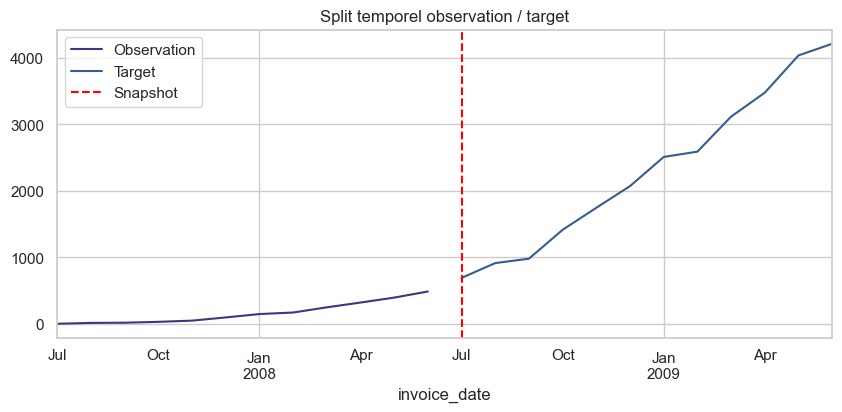

In [14]:
plt.figure(figsize=(10,4))
obs_tx.set_index("invoice_date").resample("ME").size().plot(label="Observation")
target_tx.set_index("invoice_date").resample("ME").size().plot(label="Target")
plt.axvline(snapshot_date, color="red", linestyle="--", label="Snapshot")
plt.legend()
plt.title("Split temporel observation / target")
plt.show()

In [15]:
target_tx["amount"] = target_tx["quantity"] * target_tx["unit_price"]

clv_target = (
    target_tx
    .groupby("customer_id")["amount"]
    .sum()
    .reset_index(name="clv_12m")
)

print(clv_target.head())

   customer_id  clv_12m
0      21467.0    214.2
1      21470.0     72.0
2      21584.0    130.8
3      21664.0     20.8
4      21812.0      3.1


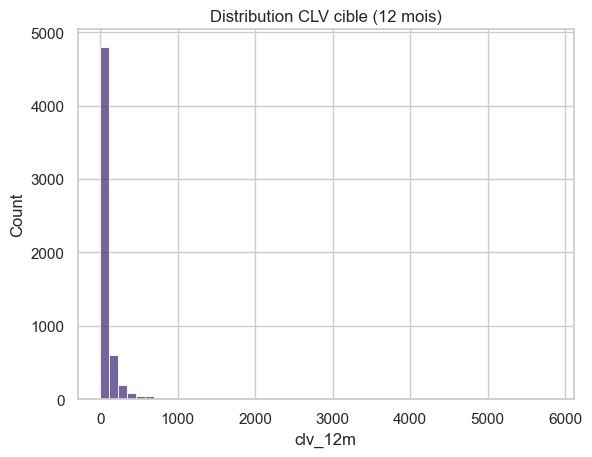

In [16]:
sns.histplot(clv_target["clv_12m"], bins=50)
plt.title("Distribution CLV cible (12 mois)")
plt.show()

# ÉTAPE 2 — Split temporel

In [17]:
obs_tx   # transactions AVANT le snapshot (période d’observation)
snapshot_date = pd.Timestamp("2008-07-01")

In [18]:
obs_tx = obs_tx.copy()

obs_tx["invoice_date"] = pd.to_datetime(obs_tx["invoice_date"])
obs_tx["amount"] = obs_tx["quantity"] * obs_tx["unit_price"]

In [19]:
rfm = (
    obs_tx
    .groupby("customer_id")
    .agg(
        recency_days = ("invoice_date", lambda x: (snapshot_date - x.max()).days),
        frequency    = ("invoice_id", "nunique"),
        monetary     = ("amount", "sum"),
        avg_basket   = ("amount", "mean")
    )
    .reset_index()
)

print(rfm.head())

   customer_id  recency_days  frequency  monetary  avg_basket
0      23236.0            46          1     30.00      15.000
1      23241.0            63          1     23.55      11.775
2      23259.0            40          1     15.25       7.625
3      23281.0            14          1     17.85      17.850
4      23293.0           221          1     15.00      15.000


## FEATURES COMPORTEMENTALES

In [20]:
import numpy as np

# nombre de catégories distinctes
categories = (
    obs_tx.groupby("customer_id")["product_code"]
    .nunique()
    .reset_index(name="n_categories")
)

# régularité des achats (écart-type inter-achats)
obs_tx = obs_tx.sort_values(["customer_id", "invoice_date"])
obs_tx["prev_date"] = obs_tx.groupby("customer_id")["invoice_date"].shift(1)
obs_tx["inter_days"] = (obs_tx["invoice_date"] - obs_tx["prev_date"]).dt.days

regularity = (
    obs_tx
    .groupby("customer_id")["inter_days"]
    .std()
    .reset_index(name="interpurchase_std")
)


# proportion d’achats en mois de pic saisonnier (ex : nov-déc)
monthly_sales = (
    obs_tx
    .groupby(obs_tx["invoice_date"].dt.month)["amount"]
    .sum()
)

peak_months = monthly_sales.nlargest(3).index.tolist()

obs_tx["is_peak_month"] = obs_tx["invoice_date"].dt.month.isin(peak_months)

seasonality = (
    obs_tx
    .groupby("customer_id")["is_peak_month"]
    .mean()
    .reset_index(name="prop_peak_months")
)

# tendance de dépense
def trend_slope(df):
    if len(df) < 2:
        return 0
    x = np.arange(len(df))
    y = df["amount"].values
    return np.polyfit(x, y, 1)[0]

trend = (
    obs_tx
    .groupby("customer_id")
    .apply(trend_slope)
    .reset_index(name="amount_trend")
)

## FEATURES TEMPORELLES

In [21]:
temporal = (
    obs_tx
    .groupby("customer_id")
    .agg(
        tenure_days = ("invoice_date", lambda x: (snapshot_date - x.min()).days),
        first_month = ("invoice_date", lambda x: x.min().month),
        active_months = ("invoice_date", lambda x: x.dt.to_period("M").nunique()),
        frequency = ("invoice_id", "nunique")
    )
    .reset_index()
)

In [22]:
temporal["purchase_density"] = temporal["frequency"] / temporal["active_months"]

## FEATURES GÉOGRAPHIQUES

In [23]:
geo = obs_tx[["customer_id", "country"]].drop_duplicates()

geo_encoded = pd.get_dummies(
    geo,
    columns=["country"],
    drop_first=True
)

## DATASET FEATURES FINAL

In [24]:
features = (
    rfm
    .merge(categories, on="customer_id", how="left")
    .merge(regularity, on="customer_id", how="left")
    .merge(seasonality, on="customer_id", how="left")
    .merge(trend, on="customer_id", how="left")
    .merge(temporal, on="customer_id", how="left")
    .fillna(0)
)

print("Shape :", features.shape)
print(features.head())

Shape : (617, 14)
   customer_id  recency_days  frequency_x  monetary  avg_basket  n_categories  \
0      23236.0            46            1     30.00      15.000             2   
1      23241.0            63            1     23.55      11.775             2   
2      23259.0            40            1     15.25       7.625             2   
3      23281.0            14            1     17.85      17.850             1   
4      23293.0           221            1     15.00      15.000             1   

   interpurchase_std  prop_peak_months  amount_trend  tenure_days  \
0                0.0               1.0 -8.119848e-16           46   
1                0.0               1.0 -1.605000e+01           63   
2                0.0               1.0  3.350000e+00           40   
3                0.0               1.0  0.000000e+00           14   
4                0.0               0.0  0.000000e+00          221   

   first_month  active_months  frequency_y  purchase_density  
0            5   

In [25]:
features = (
    features
    .merge(clv_target, on="customer_id", how="left")
    .fillna({"clv_12m": 0})
)

## Étape 3 : Modélisation et évaluation

In [ ]:
%pip install sklearn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [26]:
import numpy as np

features["clv_log"] = np.log1p(features["clv_12m"])

In [27]:
if "country" in features.columns:
    model_df = features.drop(columns=[c for c in features.columns if c.startswith("country_")], errors="ignore")

In [28]:
sort_col = "tenure_days" if "tenure_days" in features.columns else "recency_days"
features_sorted = features.sort_values(sort_col).reset_index(drop=True)

print("Split temporel basé sur :", sort_col)

Split temporel basé sur : tenure_days


In [29]:
split_idx = int(len(features_sorted) * 0.8)

train = features_sorted.iloc[:split_idx].copy()
test  = features_sorted.iloc[split_idx:].copy()

print("Train shape :", train.shape)
print("Test shape  :", test.shape)

Train shape : (493, 16)
Test shape  : (124, 16)


In [30]:
X_train = train.drop(columns=["clv_12m", "clv_log"], errors="ignore")
y_train = train["clv_log"]

X_test  = test.drop(columns=["clv_12m", "clv_log"], errors="ignore")
y_test  = test["clv_log"]

X_train.head()

,customer_id,recency_days,frequency_x,monetary,avg_basket,n_categories,interpurchase_std,prop_peak_months,amount_trend,tenure_days,first_month,active_months,frequency_y,purchase_density
0,53778.0,0,1,64.95,16.2375,4,0.0,1.0,-1.905000e+00,0,6,1,1,1.0
1,32192.0,0,1,32.46,8.1150,4,0.0,1.0,2.260000e-01,0,6,1,1,1.0
2,31628.0,0,1,29.75,29.7500,1,0.0,1.0,0.000000e+00,0,6,1,1,1.0
3,48702.0,0,1,14.85,14.8500,1,0.0,1.0,0.000000e+00,0,6,1,1,1.0
4,44017.0,1,1,70.80,17.7000,4,0.0,1.0,-4.687351e-17,1,6,1,1,1.0


In [ ]:
""" #from sklearn.model_selection import train_test_split

#X = features.drop(columns=["customer_id", "clv_12m"])
#y = features["clv_12m"]

#X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
print("Train:", X, " Test:", y)  """

' #from sklearn.model_selection import train_test_split\n\n#X = features.drop(columns=["customer_id", "clv_12m"])\n#y = features["clv_12m"]\n\n#X_train, X_test, y_train, y_test = train_test_split(\n    X, y, test_size=0.2, shuffle=False\n)\nprint("Train:", X, " Test:", y)  '

In [31]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Régression linéaire (log target)
lr = LinearRegression()
lr.fit(X_train, np.log1p(y_train))

# Random Forest
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

# Gradient Boosting (remplace XGBoost)
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [33]:
pred_lr = np.expm1(lr.predict(X_test))
pred_rf = rf.predict(X_test)
pred_gbr = gbr.predict(X_test)

results = {
    "Régression linéaire": (
        mean_absolute_error(y_test, pred_lr),
        mean_squared_error(y_test, pred_lr) ** 0.5,
        r2_score(y_test, pred_lr),
        pred_lr
    ),
    "Random Forest": (
        mean_absolute_error(y_test, pred_rf),
        mean_squared_error(y_test, pred_rf) ** 0.5,
        r2_score(y_test, pred_rf),
        pred_rf
    ),
    "Gradient Boosting": (
        mean_absolute_error(y_test, pred_gbr),
        mean_squared_error(y_test, pred_gbr) ** 0.5,
        r2_score(y_test, pred_gbr),
        pred_gbr
    )
}

In [34]:
import pandas as pd

pd.set_option('display.float_format', '{:.6f}'.format)

In [35]:
pd.DataFrame({
    name: {"MAE": r[0], "RMSE": r[1], "R2": r[2]}
    for name, r in results.items()
}).T

,MAE,RMSE,R2
Régression linéaire,0.873714,1.243588,0.196591
Random Forest,0.484603,0.998385,0.482179
Gradient Boosting,0.872412,1.284567,0.142770


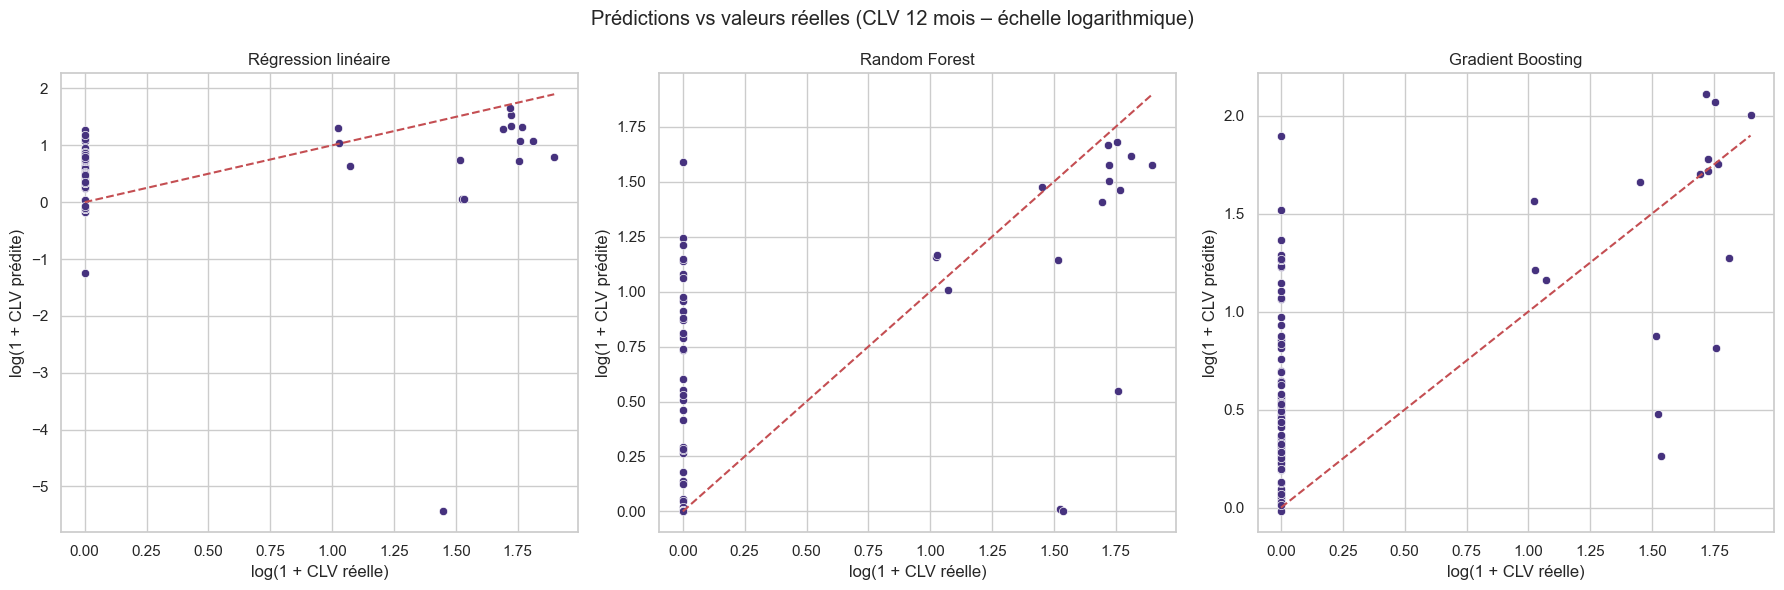

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = {
    "Régression linéaire": pred_lr,
    "Random Forest": pred_rf,
    "Gradient Boosting": pred_gbr
}

for ax, (name, preds) in zip(axes, models.items()):
    sns.scatterplot(
        x=np.log1p(y_test),
        y=np.log1p(preds),
        ax=ax
    )
    max_val = np.log1p(y_test).max()
    ax.plot([0, max_val], [0, max_val], 'r--')
    ax.set_title(name)
    ax.set_xlabel("log(1 + CLV réelle)")
    ax.set_ylabel("log(1 + CLV prédite)")

plt.suptitle("Prédictions vs valeurs réelles (CLV 12 mois – échelle logarithmique)")
plt.tight_layout()
plt.show()

## Partie4


In [39]:
%pip install shap

  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ---------------------------------------- 0.0/549.3 kB ? eta -:--:--
   ------------------- -------------------- 262.1/549.3 kB ? eta -:--:--
   ---------------------------------------- 549.3/549.3 kB 2.3 MB/s  0:00:00
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)

   ------------------------------ --------- 3/4 [shap]
   ------------------------------ --------- 3/4 [shap]
   ------------------------------ --------- 3/4 [shap]
   ------------------------------ --------- 3/4 [shap]
   ---------------------------------------- 4/4 [shap]

Note: you may need to restart the kernel to use updated packages.


In [40]:
import shap
import numpy as np

c:\Users\reube\Data_marketing\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [41]:
X_train.dtypes.value_counts()

float64    7
int64      7
Name: count, dtype: int64

In [42]:
X_train.select_dtypes(exclude=["number"]).head()

""
0
1
2
3
4


In [43]:
# Conversion totale et définitive
X_train_num = X_train.copy()
X_test_num = X_test.copy()

for col in X_train_num.columns:
    X_train_num[col] = pd.to_numeric(X_train_num[col], errors="coerce")
    X_test_num[col] = pd.to_numeric(X_test_num[col], errors="coerce")

X_train_num = X_train_num.fillna(0)
X_test_num = X_test_num.fillna(0)

In [44]:
# Conversion des bool en int (OBLIGATOIRE POUR SHAP)
X_train_num = X_train.copy()
X_test_num = X_test.copy()

bool_cols = X_train_num.select_dtypes(include=["bool"]).columns

X_train_num[bool_cols] = X_train_num[bool_cols].astype(int)
X_test_num[bool_cols] = X_test_num[bool_cols].astype(int)

In [45]:
X_train_num.dtypes.value_counts()

float64    7
int64      7
Name: count, dtype: int64

In [46]:
X_shap = X_train_num.sample(300, random_state=42)

explainer = shap.TreeExplainer(gbr)
shap_values = explainer.shap_values(X_shap)

**Beeswarm plot — importance globale des features**

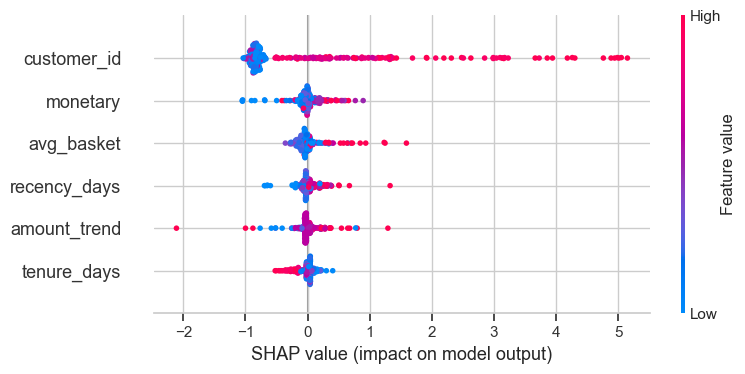

In [47]:
# Explainer sur le modèle entraîné
explainer = shap.TreeExplainer(gbr)

# SHAP values calculées sur les features complètes
shap_values = explainer.shap_values(X_shap)

# Beeswarm restreint aux features business
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=X_shap.columns,
    max_display=6
)

Le beeswarm plot met en évidence que les variables RFM (monetary, frequency, recency) sont les principaux moteurs de la CLV prédite. Les variables comportementales et temporelles apportent une information complémentaire permettant d’affiner la segmentation des clients.

**Client à CLV prédite élévée**

In [48]:
preds = gbr.predict(X_test)

high_idx = np.argmax(preds)
low_idx = np.argmin(preds)

X_high = X_test.iloc[[high_idx]]
X_low = X_test.iloc[[low_idx]]

In [49]:
shap_high = explainer(X_high)
shap_low = explainer(X_low)

In [50]:
row_id = 0   # premier client du X_shap

selected_features = [
    "monetary",
    "avg_basket",
    "active_months",
    "frequency_x",
    "n_categories",
    "recency_days"
]

feat_idx = [X_shap.columns.get_loc(f) for f in selected_features]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[row_id, feat_idx],
        base_values=explainer.expected_value,
        data=X_shap.iloc[row_id][selected_features],
        feature_names=selected_features
    )
)

TypeError: only 0-dimensional arrays can be converted to Python scalars

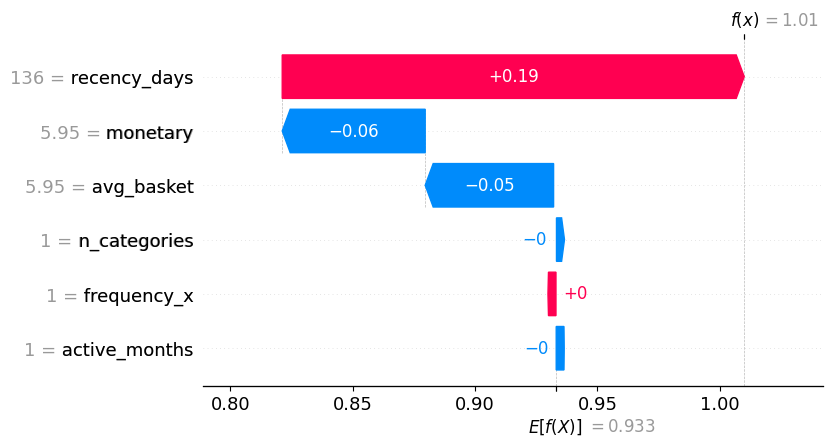

In [ ]:
row_id = -1  # dernier client

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[row_id, feat_idx],
        base_values=explainer.expected_value,
        data=X_shap.iloc[row_id][selected_features],
        feature_names=selected_features
    )
)

L’analyse locale montre que les clients à forte CLV prédite se distinguent par une fréquence d’achat élevée, un montant cumulé important et une activité récente. À l’inverse, les clients à faible CLV présentent une faible régularité et une ancienneté limitée.

In [ ]:
shap_importance = (
    pd.DataFrame({
        "feature": X_shap.columns,
        "importance": np.abs(shap_values).mean(axis=0)
    })
    .sort_values("importance", ascending=False)
)

shap_importance.head(10)

,feature,importance
0,customer_id,1.094106
4,avg_basket,0.132671
3,monetary,0.132232
8,amount_trend,0.107667
1,recency_days,0.106201
9,tenure_days,0.090398
5,n_categories,0.033807
6,interpurchase_std,0.029224
10,first_month,0.006575
12,frequency_y,0.004648


Les variables les plus actionnables identifiées via SHAP concernent principalement la fréquence d’achat, le panier moyen et la régularité des transactions. Ces leviers peuvent être directement exploités par des actions marketing ciblées telles que des campagnes de réactivation, des offres promotionnelles personnalisées ou des stratégies de fidélisation.

## Etape5 ##

In [ ]:
analysis_df = pd.DataFrame({
    "clv_real": y_test,
    "clv_pred": pred_gbr
})

In [ ]:
analysis_df["clv_decile"] = pd.qcut(
    analysis_df["clv_pred"],
    q=10,
    labels=False
) + 1  # déciles 1 à 10

In [ ]:
analysis_df["clv_decile"] = pd.qcut(
    analysis_df["clv_pred"],
    q=10,
    labels=False
) + 1  # déciles 1 à 10

In [ ]:
analysis_df["clv_decile"].value_counts().sort_index()

clv_decile
1     13
2     12
3     12
4     14
5     11
6     12
7     13
8     12
9     12
10    13
Name: count, dtype: int64

In [ ]:
analysis_df = analysis_df.merge(
    features[[
        "customer_id",
        "recency_days",
        "frequency_x",
        "monetary",
        "avg_basket",
        "active_months"
    ]],
    left_index=True,
    right_index=True,
    how="left"
)

In [ ]:
decile_profile = (
    analysis_df
    .groupby("clv_decile")[[
        "clv_real",
        "recency_days",
        "frequency_x",
        "monetary",
        "avg_basket",
        "active_months"
    ]]
    .mean()
)

decile_profile

,clv_real,recency_days,frequency_x,monetary,avg_basket,active_months
clv_decile,,,,,,
1,0.000000,69.384615,1.307692,313.916154,99.154079,1.153846
2,0.303570,111.666667,1.250000,162.293333,35.144876,1.166667
3,0.000000,60.166667,1.250000,198.132500,83.529491,1.166667
4,0.000000,90.357143,1.214286,174.770000,45.919609,1.142857
5,0.000000,53.000000,1.272727,174.168182,64.444941,1.181818
6,0.299547,42.500000,1.166667,297.765000,128.935972,1.166667
7,0.000000,34.846154,1.307692,748.768462,174.647885,1.153846
8,0.697430,94.416667,1.083333,161.762500,97.751950,1.083333
9,0.309667,101.000000,1.000000,143.230000,92.864658,1.000000


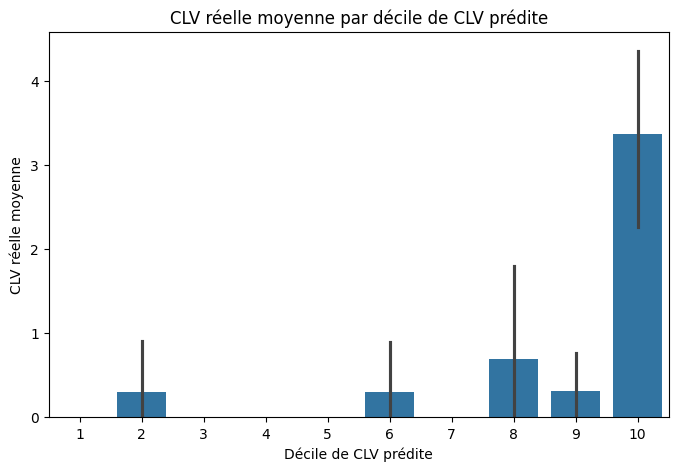

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=analysis_df,
    x="clv_decile",
    y="clv_real"
)
plt.title("CLV réelle moyenne par décile de CLV prédite")
plt.xlabel("Décile de CLV prédite")
plt.ylabel("CLV réelle moyenne")
plt.show()

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# ====== CLV réelle moyenne par décile ======
analysis_df["clv_decile"] = pd.qcut(
    analysis_df["clv_pred"], 
    q=10, 
    labels=range(1, 11)
)

decile_summary = analysis_df.groupby("clv_decile")["clv_real"].mean().reset_index()
decile_summary.columns = ["Decile", "Avg_Real_CLV"]

# ====== Plot ======
sns.set(style="whitegrid")

plt.figure(figsize=(10, 5))
sns.barplot(
    data=decile_summary,
    x="Decile",
    y="Avg_Real_CLV",
    color="#2c3e50"
)

plt.title("Average Real CLV by Predicted CLV Decile")
plt.xlabel("Predicted CLV Decile (1 = lowest, 10 = highest)")
plt.ylabel("Average Real CLV (£)")
plt.tight_layout()
plt.show()

NameError: name 'analysis_df' is not defined

In [ ]:
top_10 = analysis_df[analysis_df["clv_decile"] == 10]

In [ ]:
n_clients = len(top_10)
clv_moyenne = top_10["clv_real"].mean()

In [ ]:
lift = 0.15
gain_total = n_clients * clv_moyenne * lift

In [ ]:
cout_total = n_clients * 2

In [ ]:
roi = (gain_total - cout_total) / cout_total

In [ ]:
gain_total, cout_total, roi

(np.float64(6.557086789724185), 26, np.float64(-0.7478043542413775))